In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
import pandas as pd

df_box4  = pd.read_csv("/Users/luty8/MHW_Project/data/interim/df_box4_eventwise_SSTprime.csv")
df_D4    = pd.read_csv("/Users/luty8/MHW_Project/data/interim/df_D4_eventwise_D.csv")
df_shelf = pd.read_csv("/Users/luty8/MHW_Project/data/interim/df_shelf_eventwise_Dstar.csv")

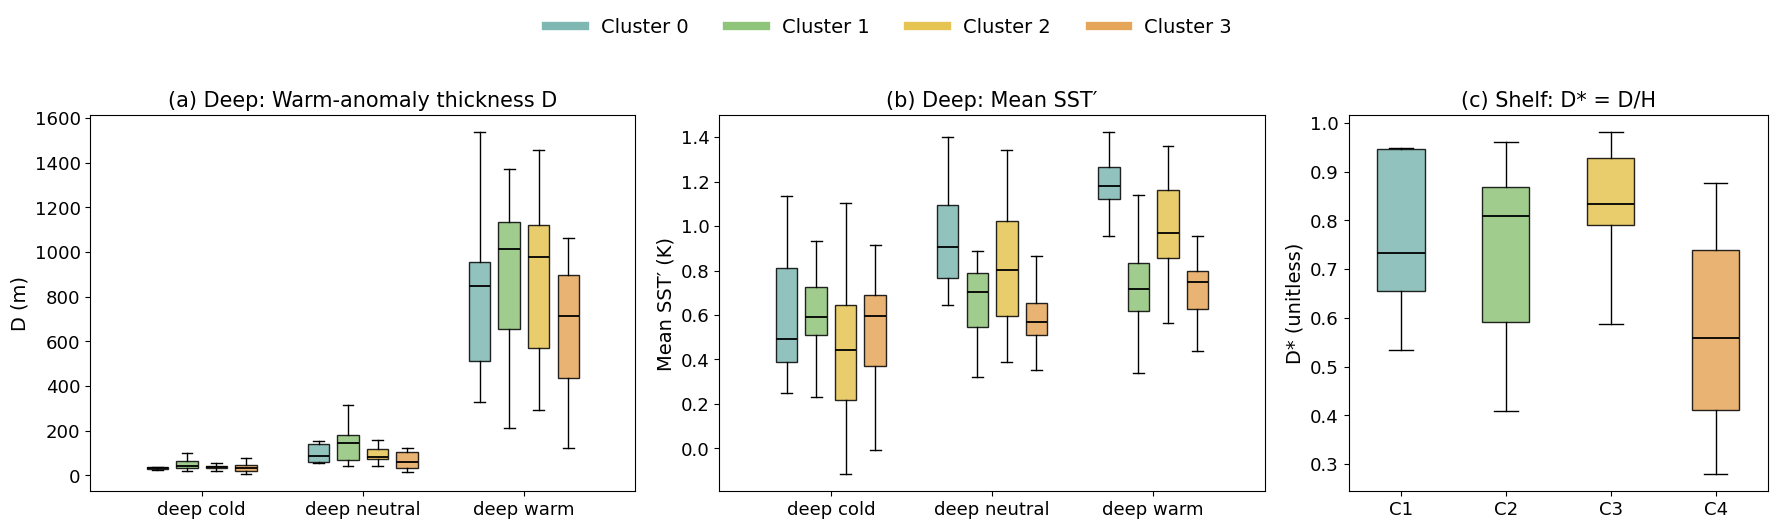

In [6]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------------
# Stronger journal-style colors
# -------------------------
cluster_colors = [
    "#7fb8b3",  # C1 深蓝绿
    "#8fc57a",  # C2 深青绿
    "#e6c451",  # C3 深黄
    "#e6a65a",  # C4 深橙
]

clusters = sorted(df_box4["cluster"].unique())
cluster_color_map = {cl: cluster_colors[i] for i, cl in enumerate(clusters)}

# -------------------------
# Global font control
# -------------------------
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
})

deep_order = ["deep_cold", "deep_neutral", "deep_warm"]
deep_tick  = ["deep cold", "deep neutral", "deep warm"]

def grouped_positions(n_groups, n_clusters, start=1.0, gap=1.2, offset=0.22):
    pos_list = []
    base = start
    for _ in range(n_groups):
        for j in range(n_clusters):
            pos_list.append(base + (j-(n_clusters-1)/2)*offset)
        base += gap
    return pos_list

nC = len(clusters)
pos_deep = grouped_positions(len(deep_order), nC)

fig, axs = plt.subplots(
    1, 3, figsize=(18, 5),
    gridspec_kw={"width_ratios":[1.3, 1.3, 1.0]}
)

# =======================
# (a) Deep D
# =======================
ax = axs[0]
data = []
for cat in deep_order:
    for cl in clusters:
        data.append(df_D4[(df_D4["category"]==cat) & (df_D4["cluster"]==cl)]["D_mean_m"].dropna().values)

bp = ax.boxplot(data, positions=pos_deep, widths=0.16,
                showfliers=False, patch_artist=True)

for i, box in enumerate(bp["boxes"]):
    cl = clusters[i % nC]
    box.set_facecolor(cluster_color_map[cl])
    box.set_alpha(0.85)
    box.set_edgecolor("black")

for med in bp["medians"]:
    med.set_color("black")
    med.set_linewidth(1.3)

ax.set_title("(a) Deep: Warm-anomaly thickness D")
ax.set_ylabel("D (m)")
ax.set_xticks([1.0, 2.2, 3.4])
ax.set_xticklabels(deep_tick)

# =======================
# (b) Deep SST′
# =======================
ax = axs[1]
data = []
for cat in deep_order:
    for cl in clusters:
        data.append(df_box4[(df_box4["category"]==cat) & (df_box4["cluster"]==cl)]["sst_bin_mean"].dropna().values)

bp = ax.boxplot(data, positions=pos_deep, widths=0.16,
                showfliers=False, patch_artist=True)

for i, box in enumerate(bp["boxes"]):
    cl = clusters[i % nC]
    box.set_facecolor(cluster_color_map[cl])
    box.set_alpha(0.85)
    box.set_edgecolor("black")

for med in bp["medians"]:
    med.set_color("black")
    med.set_linewidth(1.3)

ax.set_title("(b) Deep: Mean SST′")
ax.set_ylabel("Mean SST′ (K)")
#ax.axhline(0, color="black", linewidth=1)

ax.set_xticks([1.0, 2.2, 3.4])
ax.set_xticklabels(deep_tick)

# =======================
# (c) Shelf D*
# =======================
ax = axs[2]
clusters_s = sorted(df_shelf["cluster"].unique())
data = [df_shelf[df_shelf["cluster"]==cl]["Dstar_mean"].dropna().values
        for cl in clusters_s]

bp = ax.boxplot(data, showfliers=False, patch_artist=True)

for i, box in enumerate(bp["boxes"]):
    cl = clusters_s[i]
    box.set_facecolor(cluster_color_map[cl])
    box.set_alpha(0.85)
    box.set_edgecolor("black")

for med in bp["medians"]:
    med.set_color("black")
    med.set_linewidth(1.3)

ax.set_title("(c) Shelf: D* = D/H")
ax.set_ylabel("D* (unitless)")
ax.set_xticks(range(1, len(clusters_s)+1))
ax.set_xticklabels([f"C{cl+1}" for cl in clusters_s])

# =======================
# Legend
# =======================
legend_handles = [
    Line2D([0], [0], color=cluster_color_map[cl], lw=6, label=f"Cluster {cl}")
    for cl in clusters
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=len(clusters),
    frameon=False,
    bbox_to_anchor=(0.5, 1.08),
    fontsize=14
)

plt.tight_layout(rect=[0,0,1,0.94])
#out = OUTDIR / "fig_P3_abc_with_legend.png"
#fig.savefig(out, dpi=300, bbox_inches="tight")
plt.show()

#print("Saved:", out)


In [ ]:
DPI = 600

def save_fig(fig, name_base, outdir="."):
    pdf_path = f"{outdir}/{name_base}.pdf"
    png_path = f"{outdir}/{name_base}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")


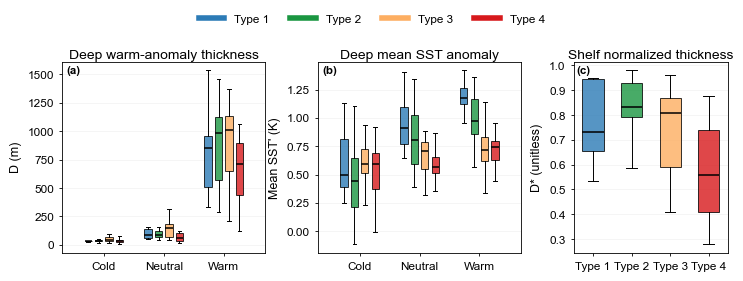

In [9]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# Journal-style settings
# ============================================================
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],

    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 8.5,

    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 2.3,
    "ytick.major.size": 2.3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ============================================================
# Colors: consistent with previous Type figures
# Type 1, Type 2, Type 3, Type 4
# (after swapping old 2 and 3)
# ============================================================
type_colors = [
    "#2c7bb6",  # Type 1
    "#1a9641",  # Type 2
    "#fdae61",  # Type 3
    "#d7191c",  # Type 4
]

# ============================================================
# Swap Type 2 and Type 3 in all source tables
# Assumes original cluster labels are 0,1,2,3
# swap order: [0,2,1,3]
# ============================================================
swap_map = {0: 0, 1: 2, 2: 1, 3: 3}

df_D4_plot = df_D4.copy()
df_box4_plot = df_box4.copy()
df_shelf_plot = df_shelf.copy()

df_D4_plot["cluster_plot"] = df_D4_plot["cluster"].map(swap_map)
df_box4_plot["cluster_plot"] = df_box4_plot["cluster"].map(swap_map)
df_shelf_plot["cluster_plot"] = df_shelf_plot["cluster"].map(swap_map)

clusters_plot = [0, 1, 2, 3]
cluster_color_map = {cl: type_colors[cl] for cl in clusters_plot}

# ============================================================
# Orders / labels
# ============================================================
deep_order = ["deep_cold", "deep_neutral", "deep_warm"]
deep_tick = ["Cold", "Neutral", "Warm"]

def grouped_positions(n_groups, n_clusters, start=1.0, gap=1.15, offset=0.20):
    pos_list = []
    base = start
    for _ in range(n_groups):
        for j in range(n_clusters):
            pos_list.append(base + (j - (n_clusters - 1) / 2) * offset)
        base += gap
    return pos_list

nC = len(clusters_plot)
pos_deep = grouped_positions(len(deep_order), nC)

# panel labels
panel_labels = ["(a)", "(b)", "(c)"]

def add_panel_label(ax, text, x=0.02, y=0.98, fontsize=8.3):
    ax.text(
        x, y, text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        fontweight="bold"
    )

def style_boxplot(bp, clusters_cycle):
    for i, box in enumerate(bp["boxes"]):
        cl = clusters_cycle[i % len(clusters_cycle)]
        box.set_facecolor(cluster_color_map[cl])
        box.set_alpha(0.80)
        box.set_edgecolor("black")
        box.set_linewidth(0.7)

    for whisk in bp["whiskers"]:
        whisk.set_color("black")
        whisk.set_linewidth(0.7)

    for cap in bp["caps"]:
        cap.set_color("black")
        cap.set_linewidth(0.7)

    for med in bp["medians"]:
        med.set_color("black")
        med.set_linewidth(1.1)

def style_axis(ax):
    ax.grid(axis="y", linewidth=0.4, alpha=0.22)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)

# ============================================================
# Figure
# ============================================================
fig, axs = plt.subplots(
    1, 3,
    figsize=(7.2, 2.9),
    gridspec_kw={"width_ratios": [1.25, 1.25, 0.95]},
    constrained_layout=False
)

# =======================
# (a) Deep D
# =======================
ax = axs[0]
data = []
for cat in deep_order:
    for cl in clusters_plot:
        data.append(
            df_D4_plot[
                (df_D4_plot["category"] == cat) &
                (df_D4_plot["cluster_plot"] == cl)
            ]["D_mean_m"].dropna().values
        )

bp = ax.boxplot(
    data,
    positions=pos_deep,
    widths=0.14,
    showfliers=False,
    patch_artist=True
)
style_boxplot(bp, clusters_plot)

add_panel_label(ax, panel_labels[0])
ax.set_title("Deep warm-anomaly thickness", pad=2.5)
ax.set_ylabel("D (m)")
ax.set_xticks([1.0, 2.15, 3.30])
ax.set_xticklabels(deep_tick)
style_axis(ax)

# =======================
# (b) Deep SST'
# =======================
ax = axs[1]
data = []
for cat in deep_order:
    for cl in clusters_plot:
        data.append(
            df_box4_plot[
                (df_box4_plot["category"] == cat) &
                (df_box4_plot["cluster_plot"] == cl)
            ]["sst_bin_mean"].dropna().values
        )

bp = ax.boxplot(
    data,
    positions=pos_deep,
    widths=0.14,
    showfliers=False,
    patch_artist=True
)
style_boxplot(bp, clusters_plot)

add_panel_label(ax, panel_labels[1])
ax.set_title("Deep mean SST anomaly", pad=2.5)
ax.set_ylabel("Mean SST' (K)")
ax.set_xticks([1.0, 2.15, 3.30])
ax.set_xticklabels(deep_tick)
style_axis(ax)

# =======================
# (c) Shelf D*
# =======================
ax = axs[2]
data = [
    df_shelf_plot[df_shelf_plot["cluster_plot"] == cl]["Dstar_mean"].dropna().values
    for cl in clusters_plot
]

bp = ax.boxplot(
    data,
    widths=0.55,
    showfliers=False,
    patch_artist=True
)

for i, box in enumerate(bp["boxes"]):
    cl = clusters_plot[i]
    box.set_facecolor(cluster_color_map[cl])
    box.set_alpha(0.80)
    box.set_edgecolor("black")
    box.set_linewidth(0.7)

for whisk in bp["whiskers"]:
    whisk.set_color("black")
    whisk.set_linewidth(0.7)

for cap in bp["caps"]:
    cap.set_color("black")
    cap.set_linewidth(0.7)

for med in bp["medians"]:
    med.set_color("black")
    med.set_linewidth(1.1)

add_panel_label(ax, panel_labels[2])
ax.set_title("Shelf normalized thickness", pad=2.5)
ax.set_ylabel("D* (unitless)")
ax.set_xticks(range(1, len(clusters_plot) + 1))
ax.set_xticklabels([f"Type {cl+1}" for cl in clusters_plot])
style_axis(ax)

# =======================
# Legend
# =======================
legend_handles = [
    Line2D([0], [0], color=cluster_color_map[cl], lw=4, label=f"Type {cl+1}")
    for cl in clusters_plot
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
    handlelength=2.2,
    columnspacing=1.8
)

fig.subplots_adjust(
    left=0.07, right=0.995,
    bottom=0.16, top=0.82,
    wspace=0.28
)

#out = OUTDIR / "fig_P3_abc_journal_style.png"
#fig.savefig(out, dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

#print("Saved:", out)